In [114]:
""" Imports and loading the data"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
csv_path = PROJECT_ROOT / "archive" / "neo_v2.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.dtypes

print("Missing values per column:")
df.isnull().sum()   # Each cell 1 / 0 -> adds them together

Shape: (90836, 10)
Missing values per column:


id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

In [115]:
""" Change hazardous from (True/False) to (1/0)"""
df["hazardous_int"] = df["hazardous"].astype(int)
df = df.drop(columns=["hazardous"])  # (boolean) dropped, hazardous_int kept

print("Remaining columns:", list(df.columns))

Remaining columns: ['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous_int']


In [116]:
""" Dropping non-informative columns """
print("Unique values in orbiting_body:", df["orbiting_body"].unique())  # Check for unique values
print("Unique values in sentry_object:", df["sentry_object"].unique())

drop_cols = ["id", "name"]
if df["orbiting_body"].nunique() == 1:  # Distinct value count, exclude Nan
    drop_cols.append("orbiting_body")
if df["sentry_object"].nunique() == 1:
    drop_cols.append("sentry_object")


df = df.drop(columns=drop_cols) # Removes columns from dataframe
print("Dropped columns:", drop_cols)
print("Remaining columns:", list(df.columns))

Unique values in orbiting_body: <StringArray>
['Earth']
Length: 1, dtype: str
Unique values in sentry_object: [False]
Dropped columns: ['id', 'name', 'orbiting_body', 'sentry_object']
Remaining columns: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [117]:
""" Correlation """
numeric_cols_with_min =  ["est_diameter_min", "est_diameter_max",
                        "relative_velocity", "miss_distance", "absolute_magnitude"]

print("Correlation between est_diameter_min and est_diameter_max:",
      df["est_diameter_min"].corr(df["est_diameter_max"]))

print()
print("Correlation of each feature with the target:")
df[numeric_cols_with_min + ["hazardous_int"]].corr()["hazardous_int"]    # Pearsons correlation coefficient

Correlation between est_diameter_min and est_diameter_max: 1.0

Correlation of each feature with the target:


est_diameter_min      0.183363
est_diameter_max      0.183363
relative_velocity     0.191185
miss_distance         0.042302
absolute_magnitude   -0.365267
hazardous_int         1.000000
Name: hazardous_int, dtype: float64

In [118]:
""" Drop est_diameter_min because of correlation with est_diameter_max"""

df = df.drop(columns=["est_diameter_min"])

numeric_cols = ["est_diameter_max", "relative_velocity", "miss_distance", "absolute_magnitude"]
print("Remaining columns:", list(df.columns))

Remaining columns: ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']


In [119]:
""" Summary of statistics"""
df[numeric_cols].describe()


,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,0.284947,48066.918918,3.706655e+07,23.527103
std,0.667491,25293.296961,2.235204e+07,2.894086
min,0.001362,203.346433,6.745533e+03,9.230000
25%,0.043057,28619.020645,1.721082e+07,21.340000
50%,0.108153,44190.117890,3.784658e+07,23.700000
75%,0.320656,62923.604633,5.654900e+07,25.700000
max,84.730541,236990.128088,7.479865e+07,33.200000


In [120]:
""" Checking "ratio" between hazardous and non-hazardous"""
print(df["hazardous_int"].value_counts())  # Count how many times hazardous int appears
print()
print(df["hazardous_int"].value_counts(normalize=True) * 100)

hazardous_int
0    81996
1     8840
Name: count, dtype: int64

hazardous_int
0    90.268176
1     9.731824
Name: proportion, dtype: float64


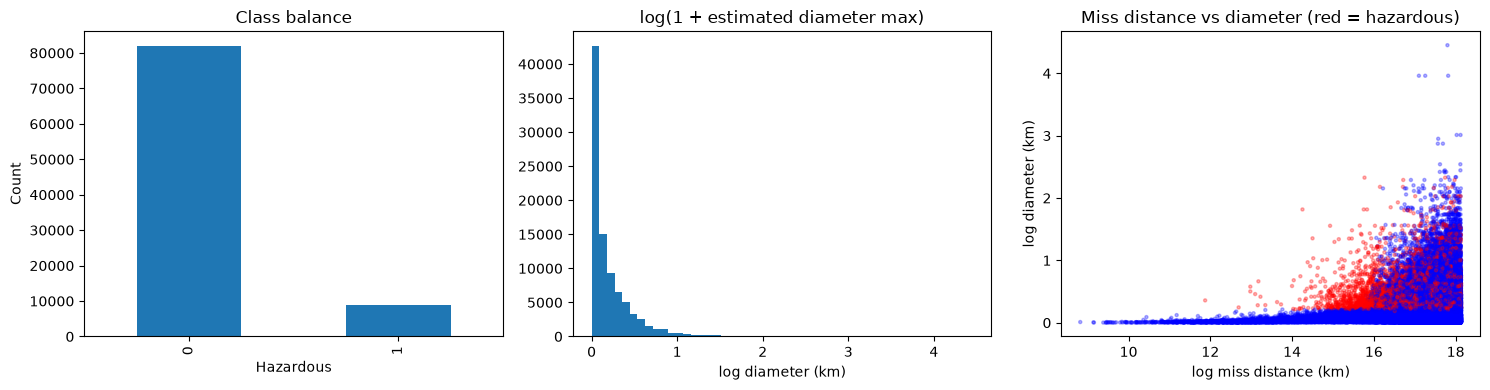

In [121]:
""" Visulaization """

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["hazardous_int"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Class balance")
axes[0].set_xlabel("Hazardous")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df["est_diameter_max"]), bins=50)
axes[1].set_title("log(1 + estimated diameter max)")
axes[1].set_xlabel("log diameter (km)")

colors = df["hazardous_int"].map({1: "red", 0: "blue"})
axes[2].scatter(np.log1p(df["miss_distance"]), np.log1p(df["est_diameter_max"]),
                 c=colors, alpha=0.3, s=5)
axes[2].set_title("Miss distance vs diameter (red = hazardous)")
axes[2].set_xlabel("log miss distance (km)")
axes[2].set_ylabel("log diameter (km)")

plt.tight_layout()
plt.show()

In [122]:
""" Save output, figures and data """

df.to_csv("clean_data.csv", index = False)
fig.savefig("plot_overview.png", dpi = 150)

print("Shape of clean_data.csv:", df.shape)
print("Columns in clean_data.csv", list(df.columns))

Shape of clean_data.csv: (90836, 5)
Columns in clean_data.csv ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous_int']
